# Joint preprocessing, filtering, and embedding of male and female PV neurons

This notebook combines male and female snRNA-seq data and selects parvalbumin (PV)–expressing neurons. The data are then used for embedding, clustering, and comparisons by sex and condition.

In [95]:
# These packages are pre-installed on Google Colab, but are included here to facilitate running this notebook locally
!pip install --quiet matplotlib
!pip install --quiet scikit-learn
!pip install --quiet numpy
!pip install --quiet scipy
!pip install --quiet pacmap
!pip install --quiet leidenalg
!pip install --quiet sinfo
# snRNA-seq analysis
!pip install --quiet scanpy
!pip install --quiet omnipath
!pip install --quiet decoupler

In [96]:
!git clone https://github.com/EugOT/CN-pr-MDD-snRNA-seq.git
%cd /content/CN-pr-MDD-snRNA-seq/

[WinError 3] Das System kann den angegebenen Pfad nicht finden: '/content/CN-pr-MDD-snRNA-seq/'
c:\Users\livle\Documents\Uni\04 Sem\04 Neuroscience\CN-pr-MDD-snRNA-seq\notebooks_review_liv


fatal: destination path 'CN-pr-MDD-snRNA-seq' already exists and is not an empty directory.


In [97]:
import os 
import random
import pacmap
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import decoupler as dc

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
from anndata.experimental.multi_files import AnnCollection

In [98]:
matplotlib.rcParams["pdf.use14corefonts"] = True
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Helvetica"]
matplotlib.rcParams["figure.max_open_warning"] = 20000

reseed = 42
random.seed(reseed)
np.random.seed(reseed)

sc.settings.verbosity = 0  # verbosity: errors (0), warnings (1), info (2), hints (3)
# sc.settings.figdir = PLOTS_DIR
sc.settings.set_figure_params(
    dpi=180, dpi_save=600, vector_friendly=True, format="pdf", transparent=True
)
sc.settings.autoshow = True
sc.settings.autosave = False

In [99]:
# Load sample-level metadata for male and female datasets


samples_males = pd.read_csv("data/PRJNA602867.tsv", delimiter="\t")
samples_males = samples_males[["Run", "Condition", "LibraryName", "BioProject", "Sex", "NTotalCells"]]

samples_females = pd.read_csv("data/PRJNA883411.tsv", delimiter="\t")
samples_females = samples_females[["Run", "Condition", "LibraryName", "BioProject", "Sex", "NTotalCells"]]

In [ ]:
# Define filtering and feature selection parameters


filtering_parameters = {
    "hvg_top_genes":6000, #orig: 5000
    "pearson_residuals_top_genes":3000, # orig: 2000
    "min_cells_per_gene":5, #orig: 10
    "min_genes_per_cell":200, #orig: 500
}

In [ ]:
# Load male dataset and attach metadata

males = sc.read_h5ad(
    "data/PRJNA602867-whole_dataset-fpr_0.001-clusters.h5ad"
)
males.obs['Run'] = males.obs['orig.ident']

# Merge cell-level annotations with sample-level metadata
males.obs = pd.merge(samples_males, males.obs, on="Run").set_index("cell_name", drop=False)
males.uns["name"] = "PRJNA602867"

# Apply basic quality control filtering
sc.pp.filter_cells(males, min_genes=filtering_parameters["min_genes_per_cell"])
sc.pp.filter_genes(males, min_cells=filtering_parameters["min_cells_per_gene"])

#Do the same for the females as we did for the males
females = sc.read_h5ad(
    "data/PRJNA883411-whole_dataset-fpr_0.001-clusters.h5ad"
)
females.obs['Run'] = females.obs['orig.ident']
females.obs = pd.merge(females.obs, samples_females, on="Run", how = "inner").set_index("cell_name", drop=False)
females.uns["name"] = "PRJNA883411"
sc.pp.filter_cells(females, min_genes=filtering_parameters["min_genes_per_cell"])
sc.pp.filter_genes(females, min_cells=filtering_parameters["min_cells_per_gene"])

In [ ]:
# Harmonize observation columns between male and female datasets

males.obs = males.obs[[
    'cell_name',
    'background_fraction',
    'droplet_efficiency',
    'doublet_score',
    'nFeature_Diff',
    'nCount_Diff',
    'percent_mito',
    'percent_ribo',
    'percent_mito_ribo',
    'percent_hb',
    'log10GenesPerUMI',
    'k_tree',
    'Run',
    'Condition',
    'BioProject',
    'Sex',
    'n_genes']]

females.obs = females.obs[[
    'cell_name',
    'background_fraction',
    'droplet_efficiency',
    'doublet_score',
    'nFeature_Diff',
    'nCount_Diff',
    'percent_mito',
    'percent_ribo',
    'percent_mito_ribo',
    'percent_hb',
    'log10GenesPerUMI',
    'k_tree',
    'Run',
    'Condition',
    'BioProject',
    'Sex',
    'n_genes']]

In [ ]:
# Join males and females datasets into a single AnnData object
adata = ad.concat([males, females], join="inner")

# Save raw counts and normalized counts for later use
adata.layers["raw"] = adata.X.copy()
adata.layers["sqrt_norm"] = np.sqrt(sc.pp.normalize_total(adata, inplace=False)["X"])
adata.raw = adata

# Apply the Pearson Residuals recipe 
sc.experimental.pp.recipe_pearson_residuals(adata, n_top_genes=2000, batch_key="Run")


In [104]:
adata

AnnData object with n_obs × n_vars = 75628 × 29727
    obs: 'cell_name', 'background_fraction', 'droplet_efficiency', 'doublet_score', 'nFeature_Diff', 'nCount_Diff', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'percent_hb', 'log10GenesPerUMI', 'k_tree', 'Run', 'Condition', 'BioProject', 'Sex', 'n_genes'
    var: 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable'
    uns: 'hvg', 'pca', 'pearson_residuals_normalization'
    obsm: 'X_pacmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw', 'sqrt_norm'

In [ ]:
# Filter neurons based on the three gene markers for PV Interneurons

pvalb_gene_index = adata.var_names.get_loc('PVALB')
gad1_gene_index = adata.var_names.get_loc('GAD1')
gad2_gene_index = adata.var_names.get_loc('GAD2')
pv_neurons_mask = (adata.X[:, pvalb_gene_index].toarray() > 0) & (adata.X[:, gad1_gene_index].toarray() > 0) & (adata.X[:, gad2_gene_index].toarray() > 0)
only_pv_neurons = adata[pv_neurons_mask]


In [ ]:
# Number of available cells per condition
adata.obs.groupby(['Condition'])['cell_name'].count().reset_index()

# Replace numeric codes with text labels for clarity (0: Control, 1:MDD)
condition_counts = (adata.obs.groupby("Condition")["cell_name"].count().reset_index())
condition_counts["Condition"] = condition_counts["Condition"].map({0: "Control", 1: "MDD"})
condition_counts


,Condition,cell_name
0,Control,38274
1,MDD,37354


In [107]:
#number of available cells per sex
adata.obs.groupby(['Sex'])['cell_name'].count().reset_index()



,Sex,cell_name
0,female,25121
1,male,50507


In [108]:
adata

AnnData object with n_obs × n_vars = 75628 × 29727
    obs: 'cell_name', 'background_fraction', 'droplet_efficiency', 'doublet_score', 'nFeature_Diff', 'nCount_Diff', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'percent_hb', 'log10GenesPerUMI', 'k_tree', 'Run', 'Condition', 'BioProject', 'Sex', 'n_genes'
    var: 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable'
    uns: 'hvg', 'pca', 'pearson_residuals_normalization'
    obsm: 'X_pacmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw', 'sqrt_norm'

In [ ]:
# Restrict dataset to PV-expressing neurons only
adata = only_pv_neurons.copy()

# Identify highly variable genes using Pearson residuals method
sc.experimental.pp.highly_variable_genes(adata, flavor="pearson_residuals", n_top_genes=filtering_parameters["hvg_top_genes"])

# Only include highly variable genes in data
adata = adata[:, adata.var["highly_variable"]]

# Combine Sex and k_tree into k_rtee
adata.obs["k_tree"] = adata.obs["Sex"].astype(str) + "_" + adata.obs["k_tree"].astype(str)


C:\Users\livle\AppData\Local\Temp\ipykernel_20472\343041223.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["k_tree"] = adata.obs["Sex"].astype(str) + "_" + adata.obs["k_tree"].astype(str)


In [ ]:
# Keep raw and depth-normalized counts for later
adata.layers["raw"] = adata.X.copy()
adata.layers["sqrt_norm"] = np.sqrt(sc.pp.normalize_total(adata, inplace=False)["X"])

# Add small constant to avoid zeros prior to log-based operations
adata.X = adata.X.toarray() + 1e-6
adata.raw = adata

# Perform normalization with recipe_pearson_residuals
sc.experimental.pp.recipe_pearson_residuals(adata, n_top_genes=filtering_parameters["pearson_residuals_top_genes"], batch_key="Run")

c:\Users\livle\miniconda3\envs\decoupler_proj\lib\site-packages\scanpy\experimental\pp\_recipes.py:125: UserWarning: `flavor='pearson_residuals'` expects raw count data, but non-integers were found.
  experimental.pp.highly_variable_genes(adata, **hvg_args, inplace=True)
c:\Users\livle\miniconda3\envs\decoupler_proj\lib\site-packages\scanpy\experimental\pp\_recipes.py:133: UserWarning: `normalize_pearson_residuals()` expects raw count data, but non-integers were found.
  experimental.pp.normalize_pearson_residuals(


In [ ]:
# Extract highly variable genes and perform dimensionality reduction with PaCMAP
hvgs = adata.var["highly_variable"]
embedding = pacmap.PaCMAP(
    n_components=2, n_neighbors=None, MN_ratio=0.5, FP_ratio=2.0, apply_pca=False
)
adata.obsm["X_pacmap"] = embedding.fit_transform(adata.obsm["X_pca"], init="pca")
n_cells = len(adata)

# Get nearest neighbours for umapping
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=50, method='umap')
sc.tl.umap(adata, method='umap')
sc.tl.leiden(adata)

2026-02-02 00:49:25 | [WARNING] Running ANNOY Indexing on high-dimensional data. Nearest-neighbor search may be slow!


In [ ]:
# Trying to find DEGs for either condition
adata.obs['ConditionCategory'] = adata.obs['Condition'].astype('category')
sc.tl.rank_genes_groups(
    adata,
    groupby="ConditionCategory",  # Column defining your groups
    method="t-test",      # You can also try 'logreg', 'wilcoxon', or 't-test_overestim_var'
    key_added="degs_condition"
)

... storing 'k_tree' as categorical
... storing 'Run' as categorical
... storing 'BioProject' as categorical
... storing 'Sex' as categorical


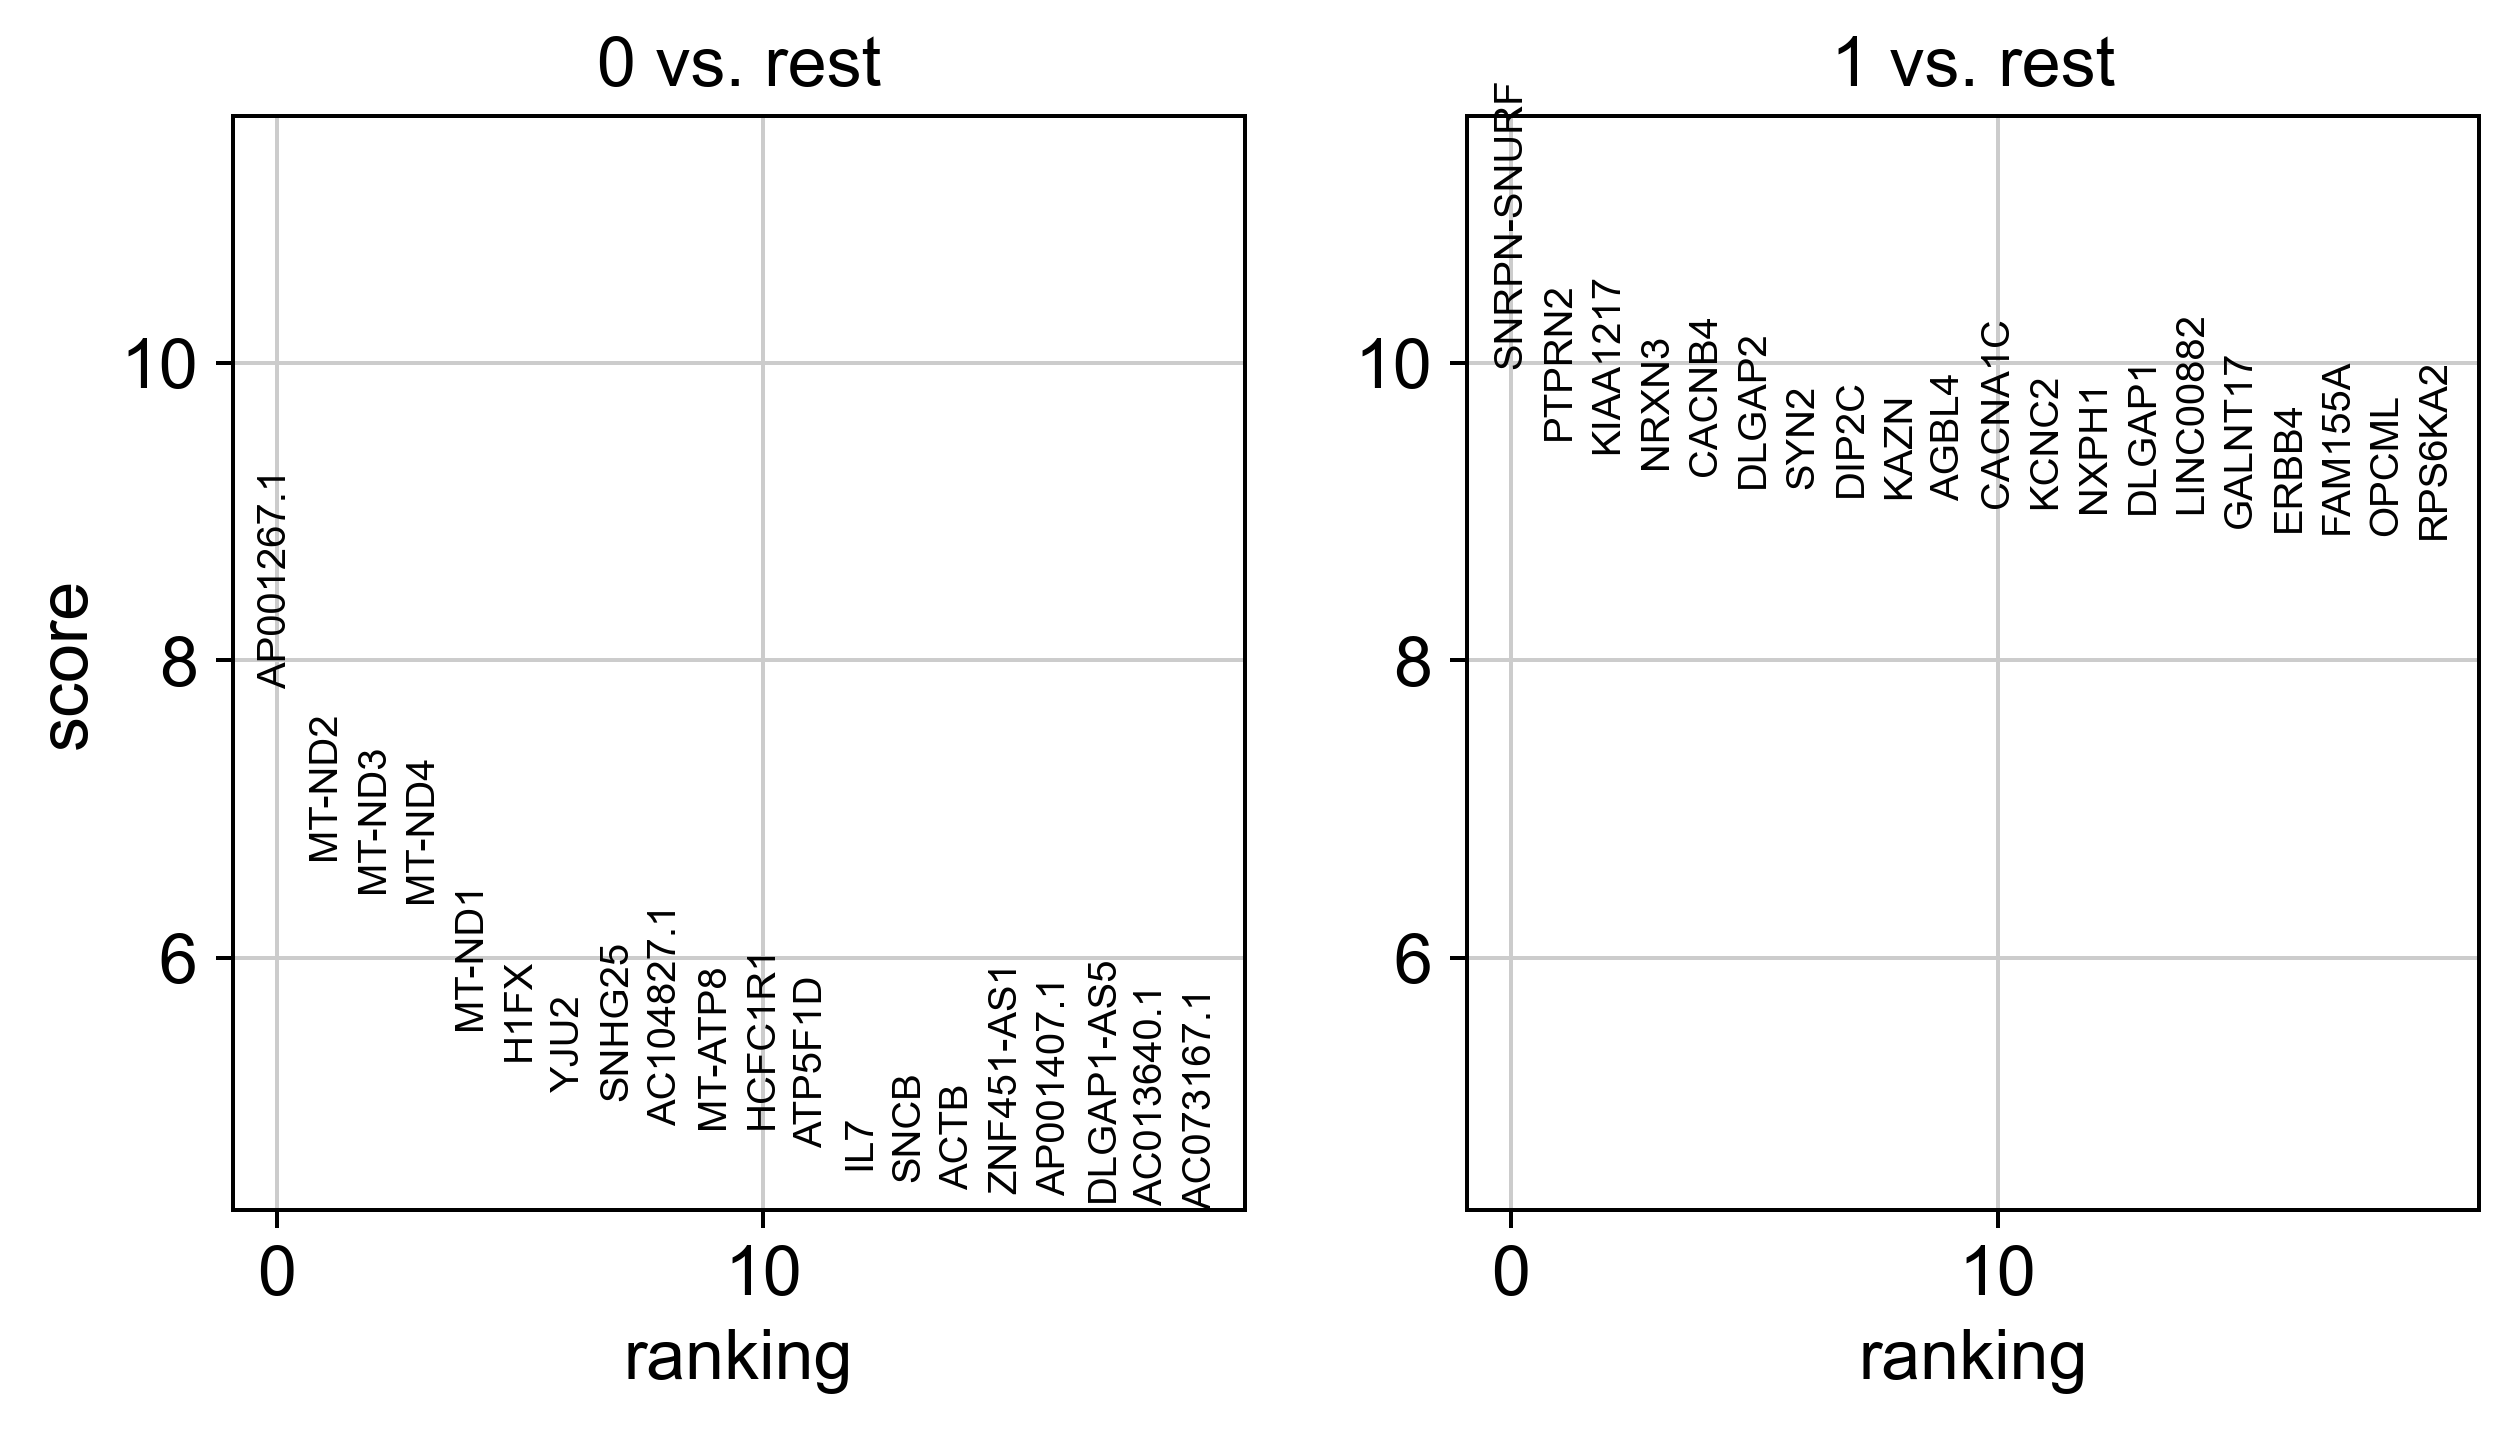

In [113]:
sc.pl.rank_genes_groups(adata, key='degs_condition')

In [ ]:
# Identify marker genes across Leiden clusters
sc.tl.rank_genes_groups(adata, 'leiden', method='logreg', key_added="leiden")

c:\Users\livle\miniconda3\envs\decoupler_proj\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


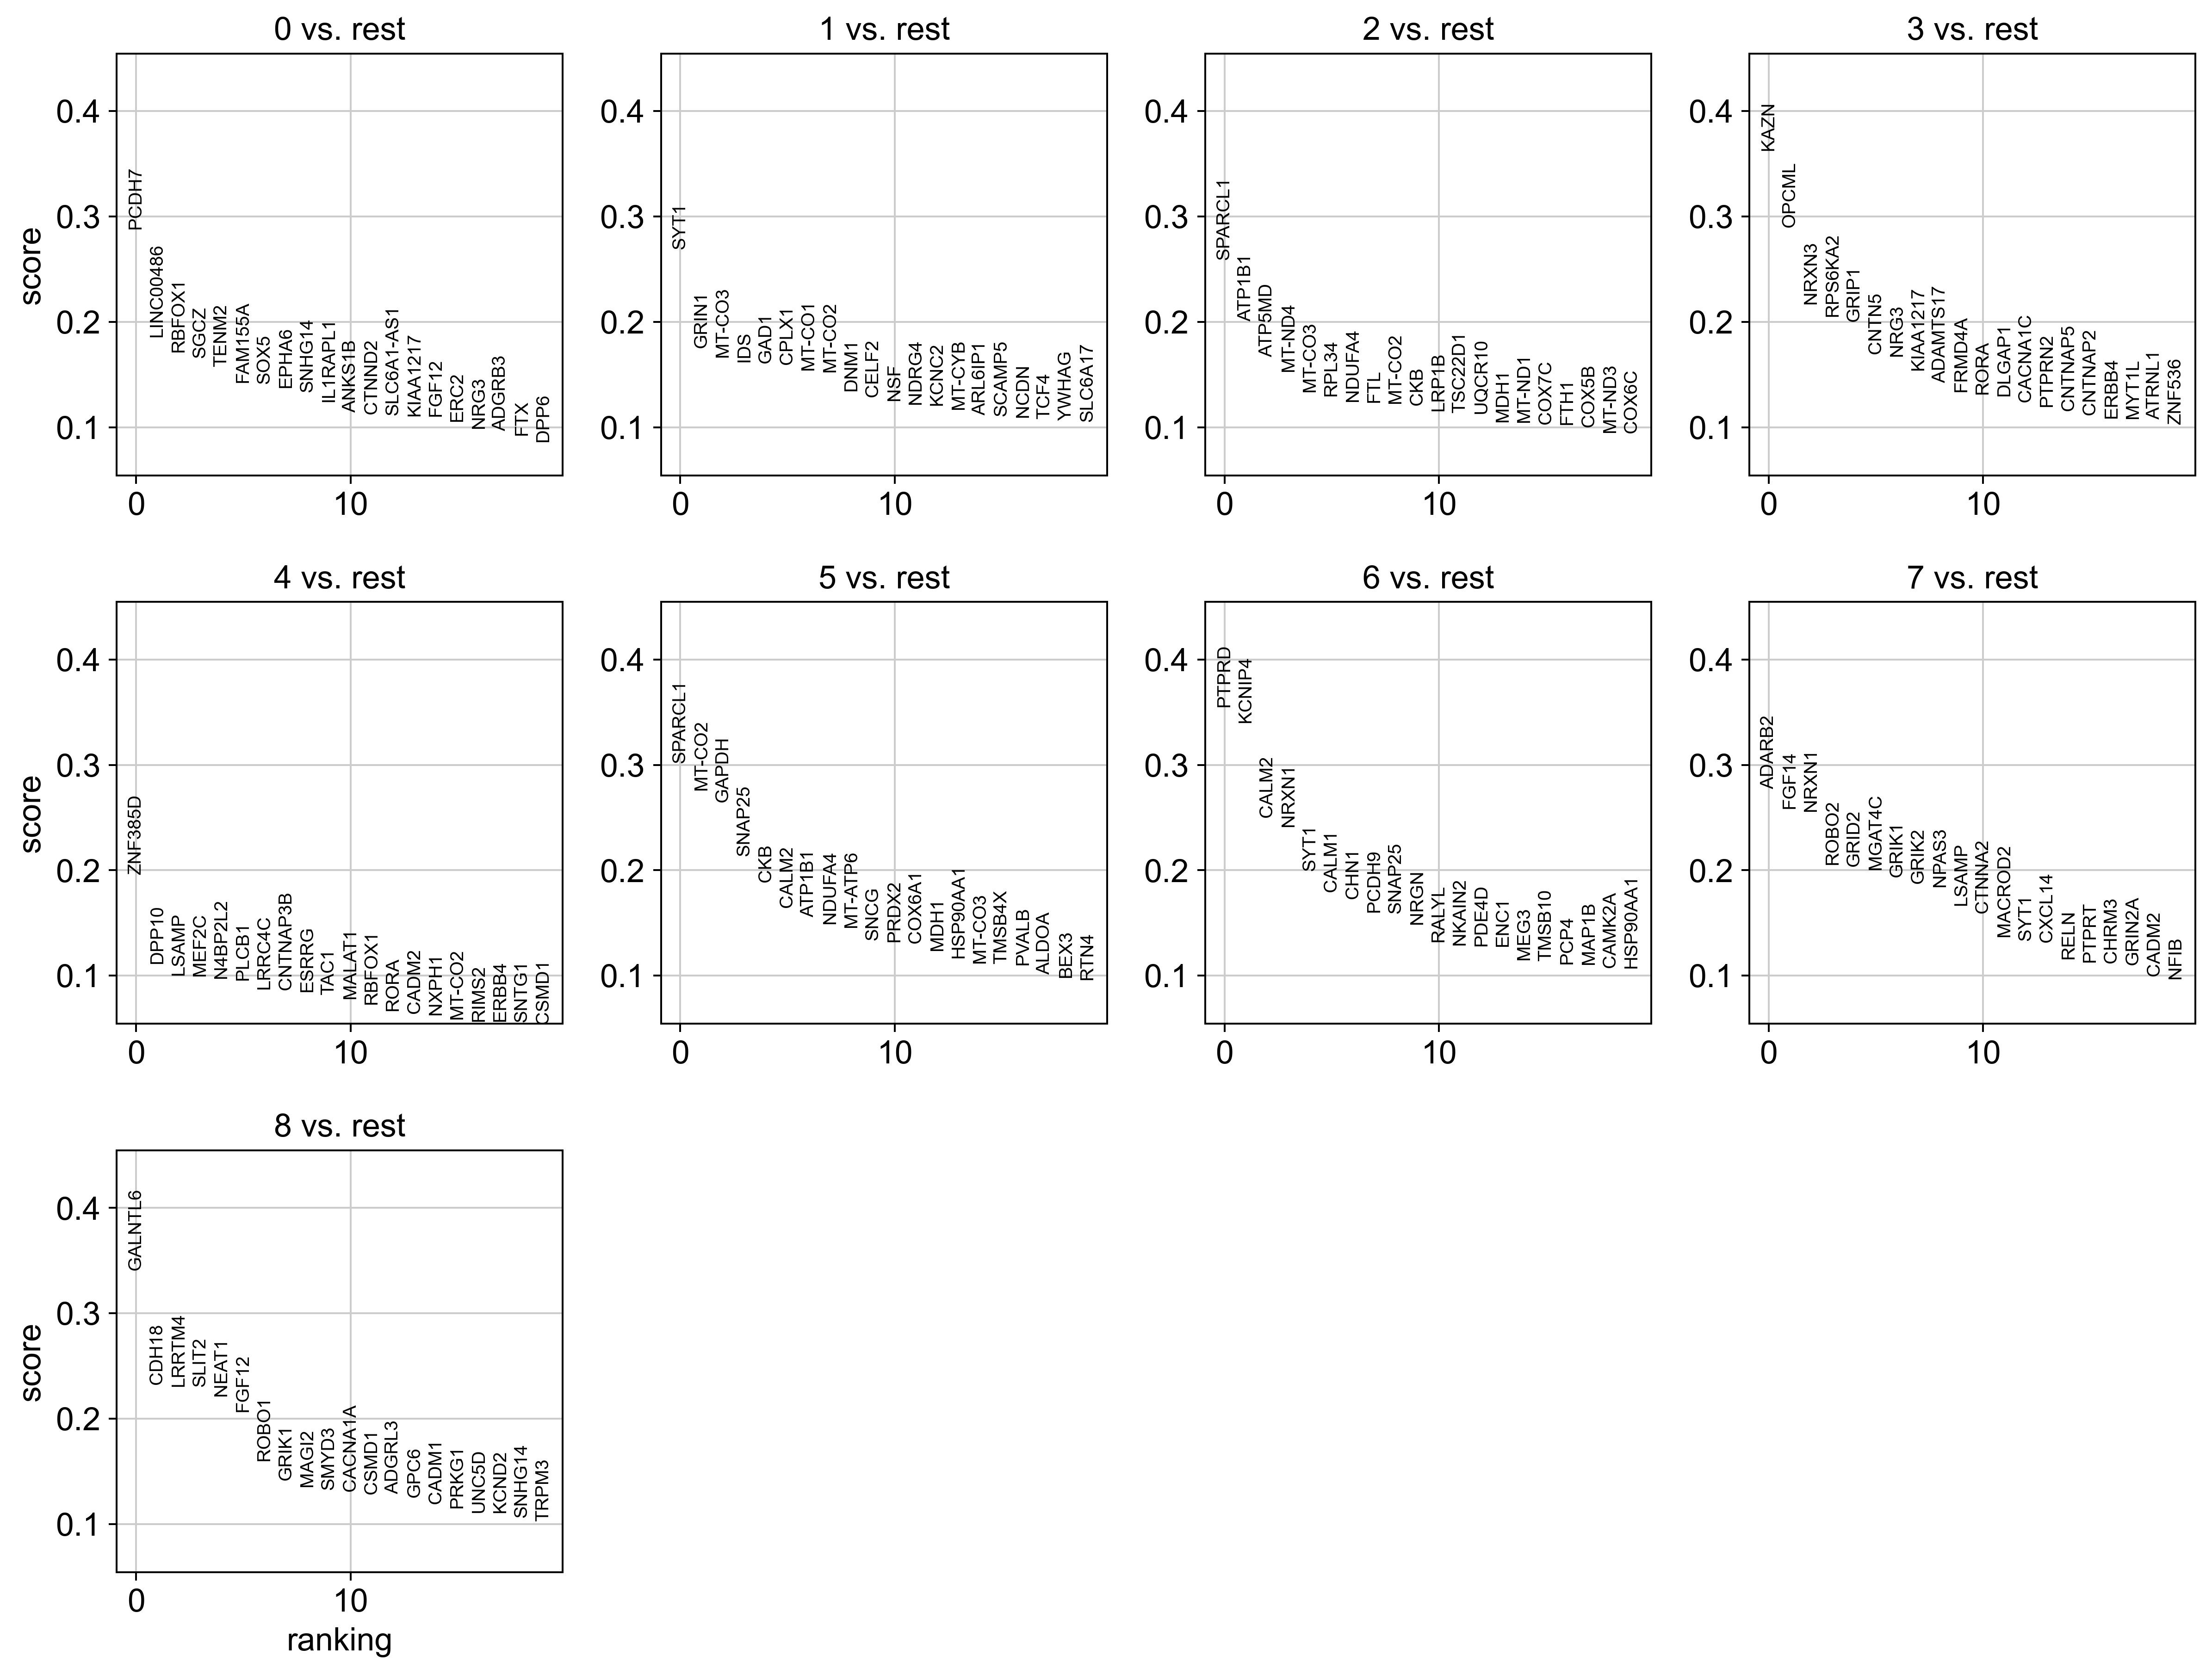

In [115]:
sc.pl.rank_genes_groups(adata, key='leiden')

In [116]:
adata

AnnData object with n_obs × n_vars = 1359 × 6000
    obs: 'cell_name', 'background_fraction', 'droplet_efficiency', 'doublet_score', 'nFeature_Diff', 'nCount_Diff', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'percent_hb', 'log10GenesPerUMI', 'k_tree', 'Run', 'Condition', 'BioProject', 'Sex', 'n_genes', 'leiden', 'ConditionCategory'
    var: 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable'
    uns: 'hvg', 'pca', 'pearson_residuals_normalization', 'neighbors', 'umap', 'leiden', 'degs_condition'
    obsm: 'X_pacmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw', 'sqrt_norm'
    obsp: 'distances', 'connectivities'

In [ ]:
# Summarize PV neuron counts per cluster and condition
adata.obs.groupby(["leiden","Condition"])["cell_name"].count().reset_index()

#Replace numeric codes with text labels for clarity (0: 'Control', 1: 'MDD)
leiden_cluster = adata.obs.groupby(["leiden","Condition"])["cell_name"].count().reset_index()
leiden_cluster['Condition'] = leiden_cluster['Condition'].map({0: 'Control', 1: 'MDD'})

leiden_cluster

C:\Users\livle\AppData\Local\Temp\ipykernel_20472\2997140297.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(["leiden","Condition"])["cell_name"].count().reset_index()
C:\Users\livle\AppData\Local\Temp\ipykernel_20472\2997140297.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  leiden_cluster = adata.obs.groupby(["leiden","Condition"])["cell_name"].count().reset_index()


,leiden,Condition,cell_name
0,0,Control,134
1,0,MDD,115
2,1,Control,133
3,1,MDD,72
4,2,Control,88
5,2,MDD,111
6,3,Control,40
7,3,MDD,157
8,4,Control,101
9,4,MDD,43
